# Data Exploration

In [2]:
#pip install pandas numpy matplotlib openpyxl

In [3]:
#Call libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import openpyxl as pxl

#Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [58]:
#Import files df
path = "../Data/"
df_data = pd.read_excel(path + 'data.xlsx')
#df_operations = pd.read_excel(path + 'Dados Operações_ Localiza.xlsm', sheet_name='Export')
df_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 33481 entries, 0 to 33480
Data columns (total 43 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Criticidade              33480 non-null  str           
 1   Regional                 33479 non-null  str           
 2   Região                   33478 non-null  str           
 3   Filial                   33479 non-null  str           
 4   Agência                  33479 non-null  str           
 5   Tipo Filial              33479 non-null  str           
 6   Placa                    33479 non-null  str           
 7   Grupo                    33479 non-null  str           
 8   Fabricante               33479 non-null  str           
 9   Modelo                   33479 non-null  str           
 10  Sit. Anterior            33479 non-null  float64       
 11  Sit. Atual               33479 non-null  float64       
 12  Data Movimentação        33479 non-null  da

In [52]:
#Analyse data types of the columns in the DataFrames -> If necessary, change the data types of the columns to the correct ones with astypte() method
df_data.dtypes
df_data.head(5)

,Criticidade,Regional,Região,Filial,Agência,Tipo Filial,Placa,Grupo,Fabricante,Modelo,...,Previsão Ent.,Entrada,Envio Orc.,Aprovação Ult. Orc.,Previsão Peça,Previsão Conclusão,Data Conclusão,Tempo Desde Ult Monit.,Ultima Frase Usuário,Retorno Mon.
0,Sit. 35 - Atenção,NDE,NDE2,CONAT,CMNAT,RAC,RUG0F66,GX,JEEP,RENEGADE LONGITUDE,...,NaT,NaT,NaT,NaT,NaT,NaT,NaT,Sit. 35,NaN,NaN
1,Manut. - Caso Crítico,COE,COE6,COSRS,ACSRS,RAC,SHB0E09,CE,HYUNDAI,HB20 LIMITED 1.0,...,2023-02-02 20:19:18.343,2023-02-03 11:00:00,2023-07-24 10:23:16.143,2023-07-24 10:25:57.500,2023-08-28 16:30:00,NaT,NaT,T: __1 dias,Peça pendente - No prazo,Em 25/07/23 às 15h51: Peça pendente - No prazo...
2,Manut. - Caso Crítico,SPI,SPI5,CONAS,CMNAS,RAC,RUG9G77,P,GENERAL MOTORS,S10 CD LS 2.8,...,2023-02-08 20:40:54.380,2023-02-09 08:51:00,2023-07-24 17:14:13.720,2023-06-09 16:09:04.760,NaT,NaT,NaT,T: __0 dias,Aguardando aprovação de orçamento,Em 26/07/23 às 12h06: Aguardando aprovação de ...
3,Manut. - Caso Crítico,SPI,SPI3,COGTA,CMGTA,RAC,RVS3F45,LE,JEEP,COMPASS LONGITUDE,...,2023-03-30 10:39:22.650,2023-04-19 12:08:00,NaT,NaT,2023-07-18 13:11:00,2023-07-28 17:00:00,NaT,T: __0 dias,Acionar Montadora (Motivo observação),Em 26/07/23 às 12h27: Acionar Montadora (Motiv...
4,Manut. - Caso Crítico,COE,COE3,COCAV,CMCAV,RAC,RUD3F49,NX,FIAT,NOVA TORO FREEDOM,...,2023-01-24 16:16:21.770,2023-01-25 16:29:00,2023-07-21 14:09:24.637,2023-07-25 18:39:27.693,2023-07-28 17:00:00,NaT,NaT,T: __0 dias,Peça Pendente – Atrasada,Em 26/07/23 às 12h15: Peça Pendente – Atrasada...


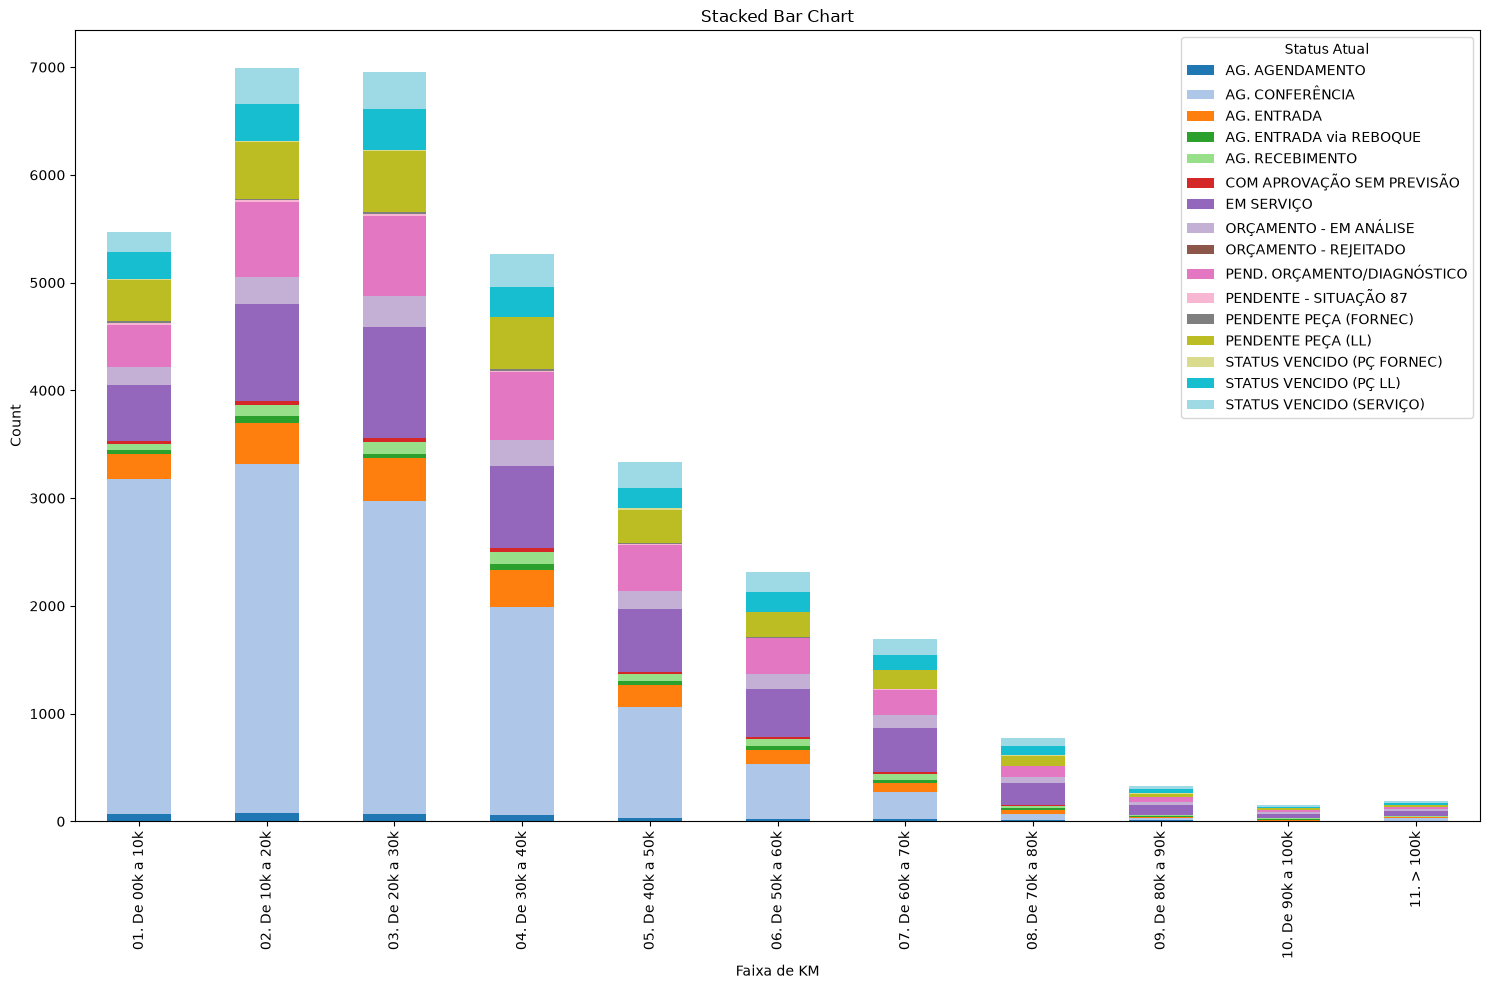

In [79]:
#Analyse the 'Faixa de KM' column and the 'Status Atual' column to check for unique values and descriptive statistics
df_data['Faixa de KM'].describe()
df_data['Faixa de KM'].unique()
df_data['Status Atual'].describe()
df_data['Status Atual'].unique()
ct = pd.crosstab(df_data['Faixa de KM'], df_data['Status Atual'])

ct.plot(kind='bar', stacked=True, figsize=(15, 10), colormap='tab20')
plt.xlabel('Faixa de KM')
plt.ylabel('Count')
plt.title('Stacked Bar Chart')
plt.legend(title='Status Atual')
plt.tight_layout()
plt.show()

#[PT-BR] -> Percebo aqui que o maior valor presente é "Ag. Conferência" e ele está ligado aos carros de até 50 km rodados
    #Hipotese 0 -> Será que os carros com até 50 km rodados são os que mais apresentam problemas de criticidade? 
    #Hipotese 1 -> Há alguma regra que se faz necessário avaliar carros com até 50 km rodados?

In [78]:
#Correction of the 'Faixa de KM' column to ensure that it is in the correct format for analysis range
df_data['Faixa de KM'] = df_data['Faixa de KM'].str.replace('01. De 0k a 10k', '01. De 00k a 10k').astype(str)

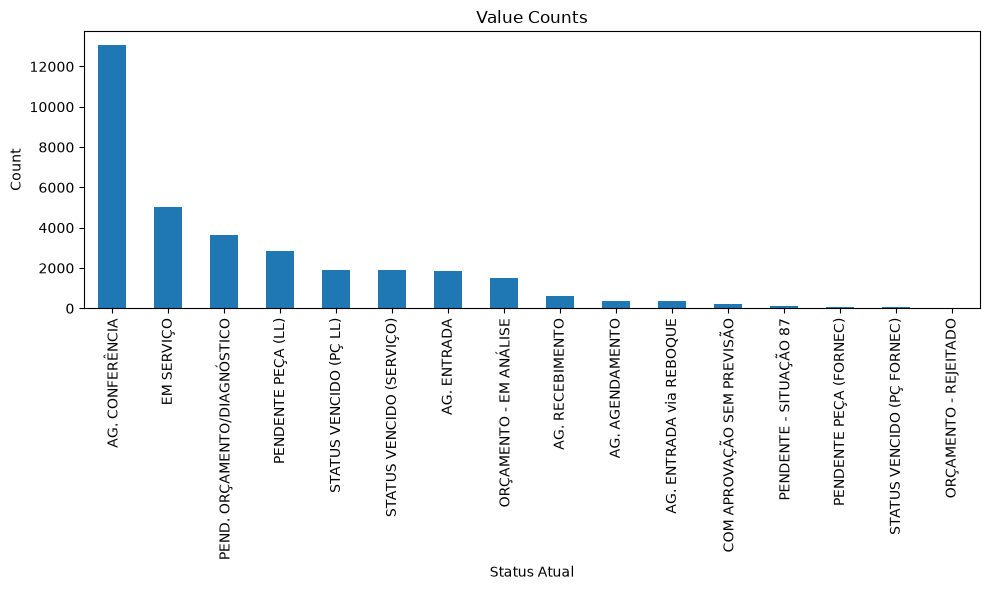

In [63]:
#Analyse the 'Status Atual' column to check for unique values and descriptive statistics
df_data['Status Atual'].describe()
df_data['Status Atual'].unique()
df_data['Status Atual'].value_counts().plot(kind='bar', figsize=(10, 6))
plt.xlabel('Status Atual')
plt.ylabel('Count')
plt.title('Value Counts')
plt.tight_layout()
plt.show()

In [73]:
#Group by and count the number of occurrences of each combination and crate a new DataFrame with the results
df_data_grouped = df_data.groupby(['Filial','Faixa de KM', 'Criticidade']).size().unstack().replace(np.nan, 0).reset_index()
cols_to_sum = df_data_grouped.columns.difference(['Filial', 'Faixa de KM'])
df_data_grouped["Total"] = df_data_grouped[cols_to_sum].sum(axis=1)
df_data_grouped = df_data_grouped.sort_values(by="Total", ascending=False).reset_index()
df_data_grouped.drop(columns=["index"], inplace=True)
df_data_grouped

Criticidade,Filial,Faixa de KM,Manut. - Caso Crítico,Manut. Abaixo 30d,Sit. 35 - Ok,Sit. 35 - Atenção,Total
0,COREC,02. De 10k a 20k,10.0,115.0,41.0,27.0,193.0
1,COVIX,02. De 10k a 20k,4.0,23.0,41.0,119.0,187.0
2,COVIX,03. De 20k a 30k,4.0,50.0,30.0,76.0,160.0
3,COSLZ,01. De 00k a 10k,5.0,41.0,46.0,67.0,159.0
4,COREC,03. De 20k a 30k,4.0,81.0,42.0,29.0,156.0
...,...,...,...,...,...,...,...
2900,COCNO,01. De 00k a 10k,0.0,1.0,0.0,0.0,1.0
2901,COZTG,02. De 10k a 20k,0.0,0.0,1.0,0.0,1.0
2902,COAGU,09. De 80k a 90k,0.0,1.0,0.0,0.0,1.0
2903,COAGR,05. De 40k a 50k,0.0,1.0,0.0,0.0,1.0


In [74]:
#A function to compute min, max, mean, median and percentage of total for each row in the DataFrame
def compute_criticidade_functions(df):
    #Columns to compute stats across, e.g. excluding 'Criticidade', 'Filial', 'Faixa de KM' and 'Total'
    cols = df.columns.difference(['Criticidade', 'Filial','Faixa de KM', 'Total'])
    
    df['min'] = df[cols].min(axis=1)
    df['max'] = df[cols].max(axis=1)
    df['mean'] = df[cols].mean(axis=1)
    df['median'] = df[cols].median(axis=1)

    #Percentage of the grand total
    df['pct_total'] = (df['Total'] / df['Total'].sum()) * 100
    
    return df

In [75]:
#Call the function to compute the statistics and add them to the DataFrame + apply a lambda function to format the percentage of total to 2 decimal places
df_data_grouped = compute_criticidade_functions(df_data_grouped)
df_data_grouped['pct_total'] = df_data_grouped['pct_total'].apply(lambda x: f"{x:.2f}%")

In [82]:
df_data_grouped
#[PT-BR] -> O que é Sit. 35?
#ct = pd.crosstab(df_data_grouped['Filial'], df_data_grouped['Faixa de KM'])
#ct

Criticidade,Filial,Faixa de KM,Manut. - Caso Crítico,Manut. Abaixo 30d,Sit. 35 - Ok,Sit. 35 - Atenção,Total,min,max,mean,median,pct_total
0,COREC,02. De 10k a 20k,10.0,115.0,41.0,27.0,193.0,10.0,115.0,48.25,34.0,0.58%
1,COVIX,02. De 10k a 20k,4.0,23.0,41.0,119.0,187.0,4.0,119.0,46.75,32.0,0.56%
2,COVIX,03. De 20k a 30k,4.0,50.0,30.0,76.0,160.0,4.0,76.0,40.00,40.0,0.48%
3,COSLZ,01. De 00k a 10k,5.0,41.0,46.0,67.0,159.0,5.0,67.0,39.75,43.5,0.47%
4,COREC,03. De 20k a 30k,4.0,81.0,42.0,29.0,156.0,4.0,81.0,39.00,35.5,0.47%
...,...,...,...,...,...,...,...,...,...,...,...,...
2900,COCNO,01. De 00k a 10k,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.25,0.0,0.00%
2901,COZTG,02. De 10k a 20k,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.25,0.0,0.00%
2902,COAGU,09. De 80k a 90k,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.25,0.0,0.00%
2903,COAGR,05. De 40k a 50k,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.25,0.0,0.00%
